In [1]:
import data
from option import args
import numpy as np
import utility
import utils
import matplotlib.pyplot as plt


/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


number of common Subjects  171


In [2]:
np.random.seed(args.seed)
ids = utils.get_ids()
# ids.sort()
total_vols = args.no_vols+args.test_vols
ids.sort()
ids = ids[:total_vols]
ids = np.random.choice(ids,total_vols,replace = False)
args.thres = 0.5
print(ids)

['104416' '128935' '109123' '115017' '102816' '125525' '105923' '130114'
 '111312' '102311' '118225' '100610' '131722' '130518' '114823' '126426'
 '111514' '116726' '115825' '108323']


In [3]:
args.test_vols = 30

In [4]:
args.no_vols = 2

In [5]:
args.type

'3d'

In [6]:
loader = data.Data(args,ids= ids,scale = [1.2,1.2,1.2])

Loading Done


In [7]:
loader.testing_dataset[0][0].shape,loader.testing_dataset[0][1].shape

(torch.Size([8, 6, 48, 48, 7]), (8, 7, 58, 58, 5))

In [8]:
loader.training_dataset[0][0].shape,loader.training_dataset[0][1].shape

(torch.Size([8, 48, 6, 48, 7]), (8, 58, 7, 58, 5))

In [9]:

def interpolate(data,size):
#     print(data.shape)
    if(len(data.shape)==3):
        inp = torch.unsqueeze(data, 0)
#         print(inp.shape)
    else:
        inp = torch.permute(data, (3,0,1,2))
    inp = torch.unsqueeze(inp, 0)
    interpolated = torch.nn.functional.interpolate(inp,size = torch.Size(size))
    interpolated = torch.permute(interpolated, (2,3,4,1,0))
    
    if(len(data.shape)==3):
        interpolated = torch.squeeze(interpolated)
    return torch.squeeze(interpolated)
    

def pnts_cord(x,pos):
    if(pos == 2):
        a,b = x[0],x[2]
        w,d = x[1]-x[0],x[3]-x[2]
        s = x[4] + (x[5]-x[4])//2
        return a,b,w,d,s
    if(pos == 0):
        a,b = x[2],x[4]
        w,d = x[3]-x[2],x[5]-x[4]
        s = x[0] + (x[1]-x[0])//2
        return a,b,w,d,s
    if(pos == 1):
        a,b = x[0],x[4]
        w,d = x[1]-x[0],x[5]-x[4]
        s = x[2] + (x[3]-x[2])//2
        return a,b,w,d,s


def align(x,y):
    temp  = x.shape[1:4]
    pos = temp.index(min(temp))
#     print(pos,temp)
    if(pos == 1):
        x = np.transpose(x,(0,1,3,2,4))
        y = np.transpose(y,(0,1,3,2,4))
    elif(pos == 0):
        x = np.transpose(x,(0,2,3,1,4))
        y = np.transpose(y,(0,2,3,1,4))
    return x,y,pos



In [10]:

%matplotlib inline

for batch, (lr, hr,scale,rel_coor,out,idx,inp_lr) in enumerate(loader.testing_data):
    
    lr = lr.squeeze().float().numpy()
    hr = hr.squeeze().float().numpy()
    inp_lr = inp_lr.squeeze().float().numpy()
    out = out.squeeze().float().numpy()
    lr,hr,pos = align(lr,hr)
    inp_lr,out,pos = align(inp_lr,out)
    
    
    rel_coor = rel_coor.squeeze()
    for j in range(8):
        
        fig, ax = plt.subplots(7,4)

        fig.set_figwidth(15)
        fig.set_figheight(15)

        fig.delaxes(ax[0][1])
        fig.delaxes(ax[1][1])
        fig.delaxes(ax[5][1])
        fig.delaxes(ax[6][1])

        fig.delaxes(ax[0][2])
        fig.delaxes(ax[1][2])
        fig.delaxes(ax[5][2])
        fig.delaxes(ax[6][2])
        
        for i in range(7):
            ax[i][0].title.set_text("HR_dwi "+str(i))
            pos = ax[i][0].imshow(lr[j,:,:,0,i])
            fig.colorbar(pos, ax=ax[i][0])
            ax[i][0].set_xticks([])
            ax[i][0].set_yticks([])
        
        for i in range(7):
            ax[i][3].title.set_text("LR_dwi "+str(i))
            pos = ax[i][3].imshow(inp_lr[j,:,:,0,i])
            fig.colorbar(pos, ax=ax[i][3])
            ax[i][3].set_xticks([])
            ax[i][3].set_yticks([])
            
        ax[0][0].title.set_text("HR_b0")
        ax[0][3].title.set_text("LR_b0")
        
        ax[2][1].title.set_text("HR_ADC")
        ax[3][1].title.set_text("HR_FA")
        ax[4][1].title.set_text("HR_RGB")
        
        pos = ax[2][1].imshow(hr[j,:,:,0,0])
        fig.colorbar(pos, ax=ax[2][1])
        pos = ax[3][1].imshow(hr[j,:,:,0,1])
        fig.colorbar(pos, ax=ax[3][1])
        pos = ax[4][1].imshow(hr[j,:,:,0,2:])
        fig.colorbar(pos, ax=ax[4][1])
        
        ax[2][2].title.set_text("LR_ADC")
        ax[3][2].title.set_text("LR_FA")
        ax[4][2].title.set_text("LR_RGB")
        pos = ax[2][2].imshow(out[j,:,:,0,0])
        fig.colorbar(pos, ax=ax[2][2])
        pos = ax[3][2].imshow(out[j,:,:,0,1])
        fig.colorbar(pos, ax=ax[3][2])
        pos = ax[4][2].imshow(out[j,:,:,0,2:])
        fig.colorbar(pos, ax=ax[4][2])
        temp = [ax[2][1],ax[3][1],ax[4][1],ax[2][2],ax[3][2],ax[4][2]]
        for i in temp:
            i.set_xticks([])
            i.set_yticks([])

        fig.suptitle(f"shape = {[i.item() for i in scale][-3:]},idx = {idx}, part = {j}")
        
        fig.savefig(f"Images/{idx,j}.jpg")
#         print(f"shape = {[i.item() for i in scale][-3:]},idx = {idx}, part = {j}")
#         break
#     break
# fig.show()
# plt.xticks([])

ValueError: not enough values to unpack (expected 7, got 6)

In [ ]:
hr.shape,lr.shape

In [ ]:

%matplotlib inline
fig, ax = plt.subplots(2,7)

# fig.set_figheight(4*5)
# set width of each subplot as 8
fig.set_figwidth(15)

# for j in range(8):
for i in range(7):
    ax[0][i].title.set_text("dwi "+str(i))
    ax[0][i].imshow(lr[0,:,:,0,i])

ax[0][0].title.set_text("b0")
ax[1][2].title.set_text("ADC")
ax[1][3].title.set_text("FA")
ax[1][4].title.set_text("RGB")
ax[1][2].imshow(hr[0,:,:,0,0])
ax[1][3].imshow(hr[0,:,:,0,1])
ax[1][4].imshow(hr[0,:,:,0,2:])
fig.delaxes(ax[1][0])
fig.delaxes(ax[1][1])
fig.delaxes(ax[1][5])
fig.delaxes(ax[1][6])
# fig.savefig(f"{idx,j}.jpg")

In [36]:
lr.shape

(8, 32, 32, 8, 7)

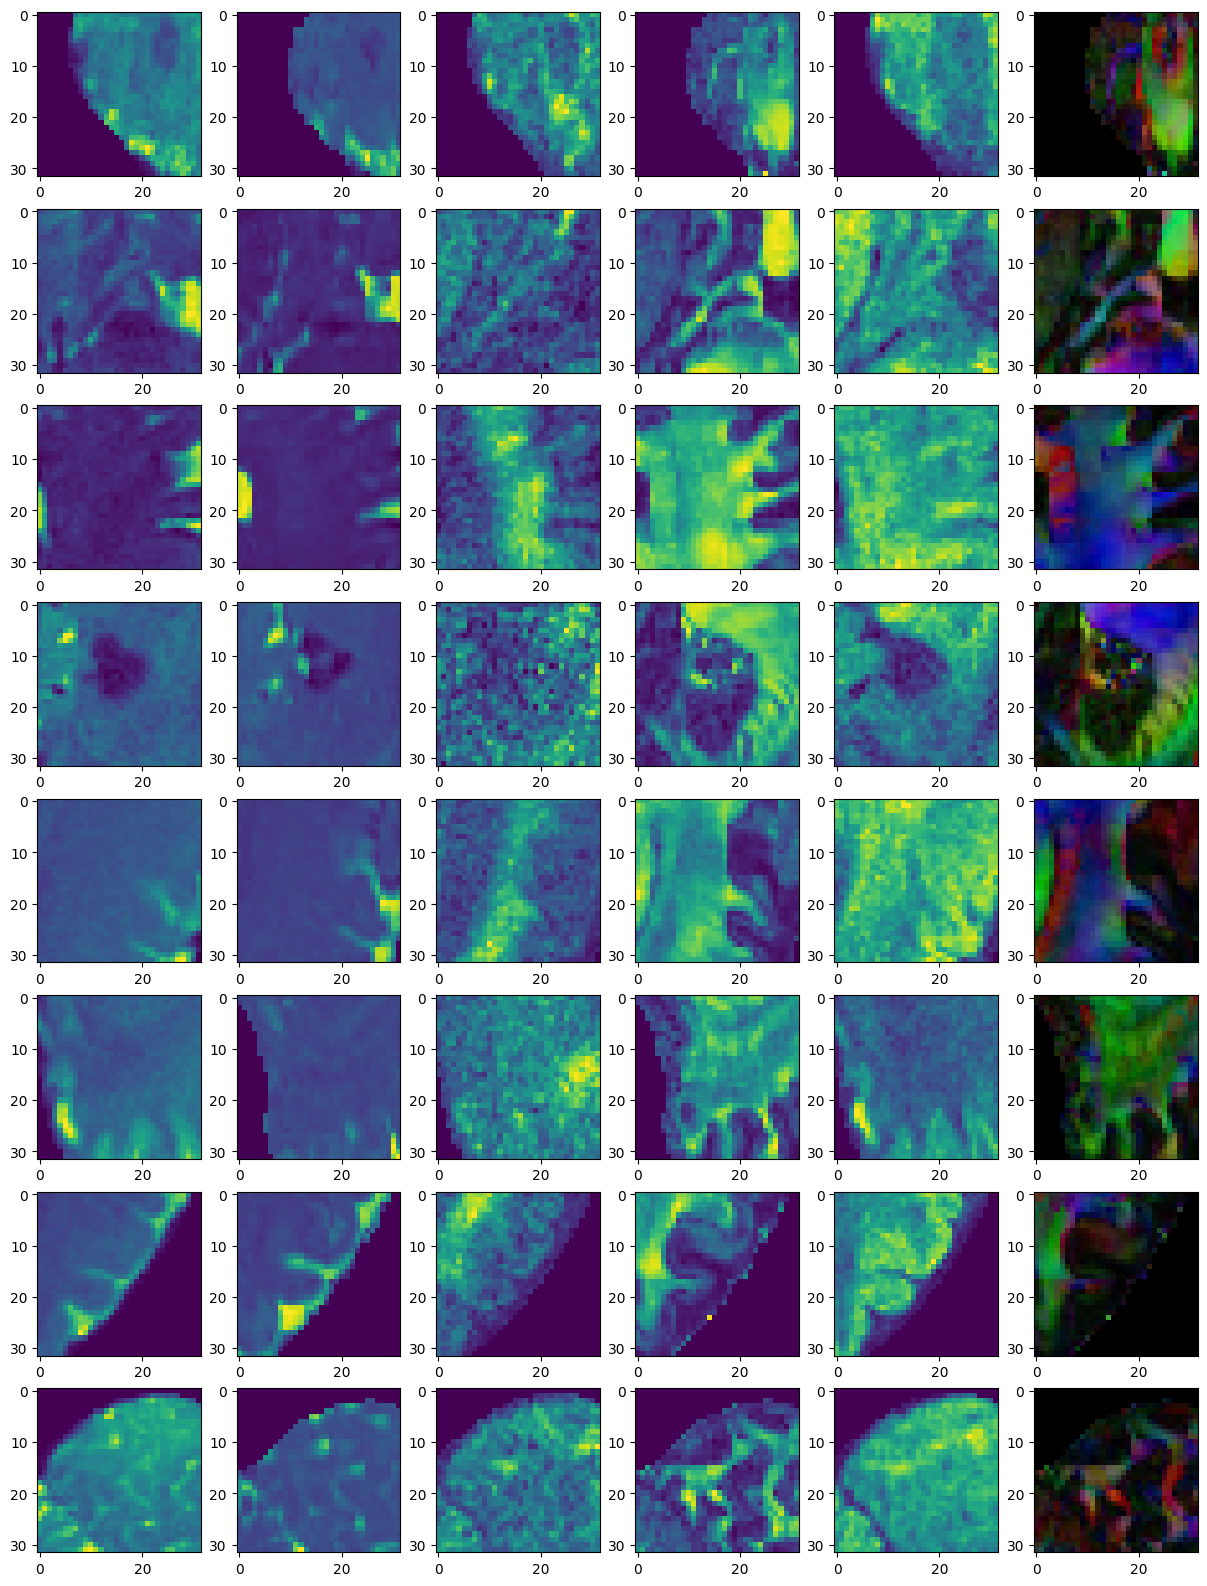

In [31]:

%matplotlib inline
fig, ax = plt.subplots(8,6)

fig.set_figheight(4*5)
# set width of each subplot as 8
fig.set_figwidth(15)
for batch, (lr, hr,scale,rel_coor) in enumerate(loader.training_data):
    lr = lr.squeeze().float().numpy()
    hr = hr.squeeze().float().numpy()
    lr,hr,pos = align(lr,hr)
#     out,hr,pos = align(out,hr)
#     print(batch)
    temp = 2*batch
    for i in range(8):
        ax[i][0].imshow(lr[i,:,:,0,0])
        ax[i][1].imshow(hr[i,:,:,0,0])
        ax[i][2].imshow(lr[i,:,:,0,1])
        ax[i][3].imshow(hr[i,:,:,0,1])
        ax[i][4].imshow(lr[i,:,:,0,2])
        ax[i][5].imshow(hr[i,:,:,0,2:])
#         ax[i][2].imshow(out[i,:,:,0,0])
    if(batch == 3):
        break
